A data analysis project on the Diabetes dataset focusing on data cleaning, preprocessing, and exploratory data analysis (EDA).

In [2]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
#load data
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.size

6912

In [4]:
df.shape

(768, 9)

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

DATA CLEANING AND PREPROCESSING:

data cleaning:
  data cleaning contains:
Handling missing values (fill or remove)
Removing duplicate records
Fixing incorrect or zero values
Converting correct data types
Standardizing column names

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [47]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [48]:
#check missing values:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [49]:
#check duplicated value
df.duplicated().sum() #no duplicate value

np.int64(0)

In [50]:
df['Pregnancies'].unique()

array([ 6,  1,  8,  0,  5,  3, 10,  2,  4,  7,  9, 11, 13, 15, 17, 12, 14])

In [5]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [6]:
df.mean()

Pregnancies                   3.845052
Glucose                     120.894531
BloodPressure                69.105469
SkinThickness                20.536458
Insulin                      79.799479
BMI                          31.992578
DiabetesPedigreeFunction      0.471876
Age                          33.240885
Outcome                       0.348958
dtype: float64

In [51]:
df['Outcome'].unique()

array([1, 0])

In [52]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [10]:
(df['Glucose'] >126).sum()

np.int64(288)

In [13]:
(df['Glucose'].min())

np.int64(0)

In [11]:
(df['BloodPressure'] > 90).sum()

np.int64(38)

In [14]:
df['BloodPressure'].mean()

np.float64(72.25480651855469)

In [12]:
df['BloodPressure'] = df['BloodPressure'].replace(0, df['BloodPressure'].mean())
df['BloodPressure']

0      72.0
1      66.0
2      64.0
3      66.0
4      40.0
       ... 
763    76.0
764    70.0
765    72.0
766    60.0
767    70.0
Name: BloodPressure, Length: 768, dtype: float64

In [7]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

<Axes: xlabel='Outcome', ylabel='count'>

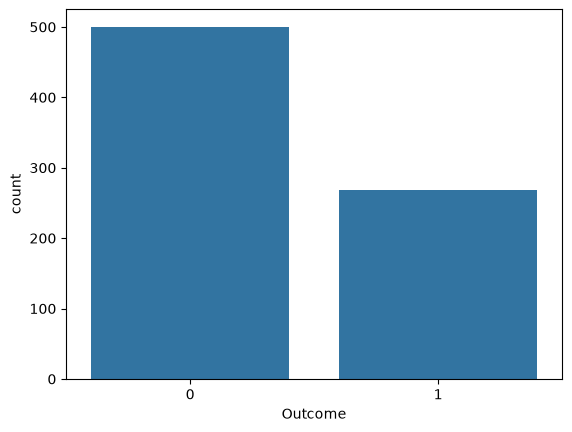

In [8]:
import seaborn as sns
sns.countplot(x='Outcome', data=df)

In [57]:
df['Outcome_Label'] = df['Outcome'].map({0:'Non-Diabetic', 1:'Diabetic'})
df['Outcome_Label'] 

0          Diabetic
1      Non-Diabetic
2          Diabetic
3      Non-Diabetic
4          Diabetic
           ...     
763    Non-Diabetic
764    Non-Diabetic
765    Non-Diabetic
766        Diabetic
767    Non-Diabetic
Name: Outcome_Label, Length: 768, dtype: str

In [37]:
df2=df.drop(['Outcome_Label'], axis=1) 
df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


FEATURE ENGINEERING:

it include:
  Creating new features from existing data.
  Transforming variables (e.g., scaling, normalization)
  Dropping irrelevant or less useful features
  Upsampling
  Downsampling
  SMOTE



In [ ]:
df['BMI_Category'] = pd.cut(df['BMI'],
                           bins=[0, 18.5, 25,30, 100],
                           labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df['BMI_Category']

0           Obese
1      Overweight
2          Normal
3      Overweight
4           Obese
          ...    
763         Obese
764         Obese
765    Overweight
766         Obese
767         Obese
Name: BMI_Category, Length: 768, dtype: category
Categories (4, str): ['Underweight' < 'Normal' < 'Overweight' < 'Obese']

In [18]:
print(df['BMI_Category'].value_counts())

BMI_Category
Obese          465
Overweight     180
Normal         108
Underweight      4
Name: count, dtype: int64


In [25]:
df['age_category'] = pd.cut(df['Age'],
                            bins=[0, 18, 35, 60, 100],
                            labels=['Teenager', 'Young Adult', 'Adult', 'Senior'])
df['age_category'].value_counts()

age_category
Young Adult    498
Adult          243
Senior          27
Teenager         0
Name: count, dtype: int64

<Axes: xlabel='Outcome', ylabel='count'>

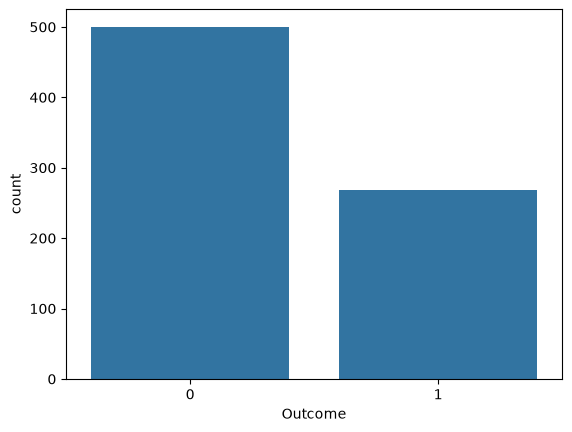

In [38]:
sns.countplot(x='Outcome', data=df)

<Axes: xlabel='Glucose', ylabel='BMI'>

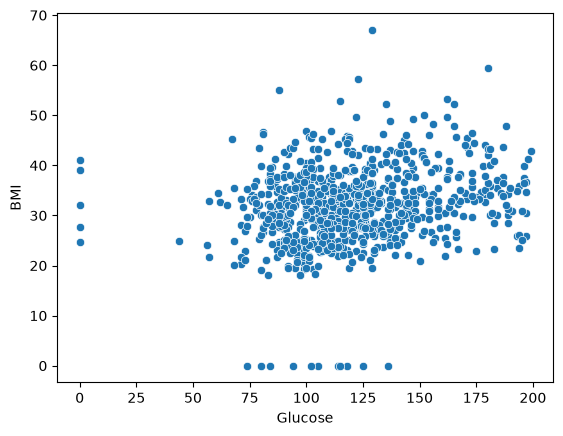

In [39]:
sns.scatterplot(x='Glucose', y='BMI', data=df)

In [23]:
df['age_category'].value_counts()

age_category
Young Adult    498
Adult          243
Senior          27
Teenager         0
Name: count, dtype: int64

Scaling:standardization and normilization:

In [41]:
#standardization: z=(x-mean)/sd.
#range betn -1 to 1.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['BMI']] = scaler.fit_transform(df[['BMI']])
df[['BMI']] 

,BMI
0,0.204013
1,-0.684422
2,-1.103255
3,-0.494043
4,1.409746
...,...
763,0.115169
764,0.610154
765,-0.735190
766,-0.240205


In [42]:
#Normalization: x'=(x-min)/(max-min)
#range betn 0 to 1.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Pregnancies']] = scaler.fit_transform(df[['Pregnancies']])
df[['Pregnancies']] 

,Pregnancies
0,0.352941
1,0.058824
2,0.470588
3,0.058824
4,0.000000
...,...
763,0.588235
764,0.117647
765,0.294118
766,0.058824


In [65]:
from sklearn.utils import resample

# Separate classes
df_majority = df[df['Outcome'] == 0]
df_minority = df[df['Outcome'] == 1]

# Upsample minority
df_minority_upsampled = resample(df_minority,
                                replace=True,   # allow duplicates
                                n_samples=len(df_majority),
                                random_state=42)
df_upsampled = pd.concat([df_majority, df_minority_upsampled])
df_upsampled['Outcome'].value_counts()

Outcome
0    500
1    500
Name: count, dtype: int64

In [62]:
#downsampling
df_majority_downsampled = resample(df_majority,
                                  replace=False,   # no duplicate
                                  n_samples=len(df_minority),  # match minority
                                  random_state=42)

# Combine both classes
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Check new counts
print(df_balanced['Outcome'].value_counts())



Outcome
0    268
1    268
Name: count, dtype: int64


In [70]:
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(pd.Series(y_resampled).value_counts())

Outcome
1    500
0    500
Name: count, dtype: int64


EDA(Exploratory Data Analysis)
     Exploratory Data Analysis (EDA) is the process of analyzing and understanding a dataset before applying any machine learning models.
      tt includes:
Graphical representation of data
Helps understand patterns and trends
Makes data easy to interpret
Includes charts like histogram, bar chart, line plot, boxplot, scatter plot, heatmap

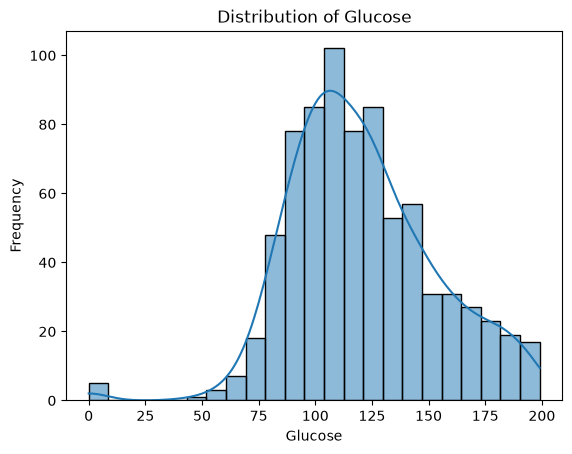

In [33]:
sns.histplot(df['Glucose'], kde=True)
plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

-The histogram shows that a large number of individuals have glucose levels between 100 and 125.The distribution indicates that higher glucose levels are common and may be linked to increased diabetes risk.

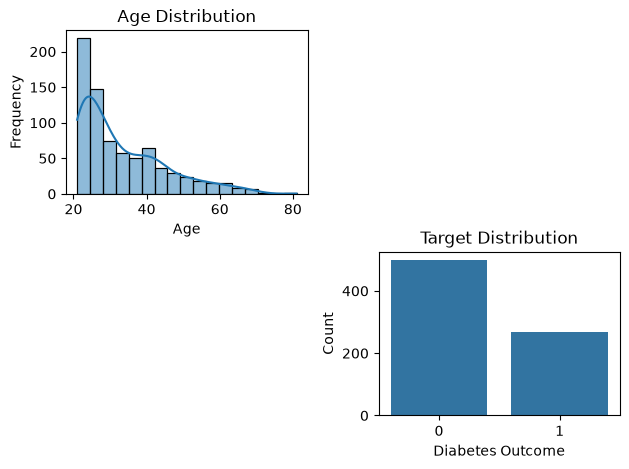

In [37]:

# 1. Age Distribution
plt.subplot(2,2,1)
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")





# 4. Target Count Distribution
plt.subplot(2,2,4)
sns.countplot(x='Outcome', data=df)
plt.title("Target Distribution")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Count")


plt.tight_layout()
plt.show()

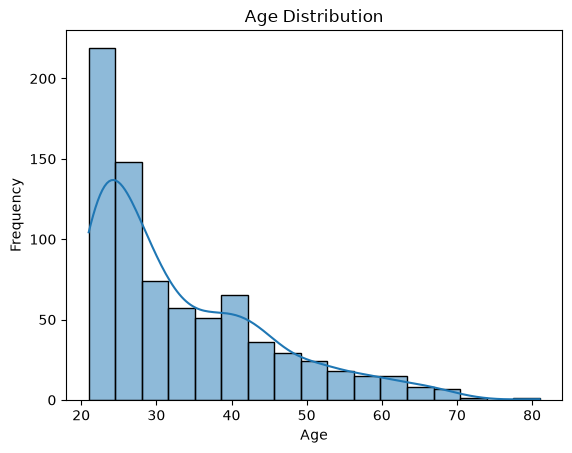

In [35]:

sns.histplot(df['Age'],kde='True')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

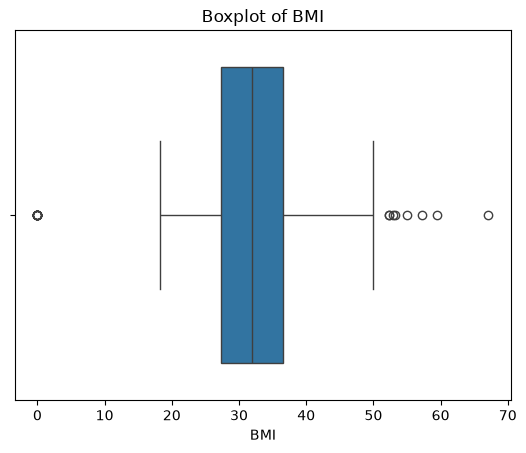

In [73]:
sns.boxplot(x=df['BMI'])
plt.title("Boxplot of BMI")
plt.show()


-The boxplot of BMI shows that most values are concentrated between approximately 25 and 35, with a median around 30, indicating that many individuals fall in the overweight range.

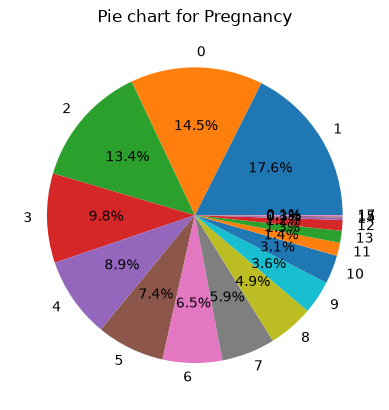

In [ ]:

# Plot pie chart
import matplotlib.pyplot as plt
counts = df['Pregnancies'].value_counts()
plt.pie(counts,
        labels=counts.index,
        autopct='%1.1f%%')
plt.title('Pie chart for Pregnancy')
plt.show()

The pie chart shows the distribution of individuals based on the number of pregnancies. The largest portions are for 1 pregnancy (17.6%), 0 pregnancies (14.5%), and 2 pregnancies (13.4%), indicating that most individuals have a low number of pregnancies. As the number of pregnancies increases, the percentage gradually decreases. Very high pregnancy counts (such as 10 and above) have very small proportions, showing that they are rare in the dataset. Overall, the chart indicates that lower pregnancy counts are more common, while higher counts are less frequent.

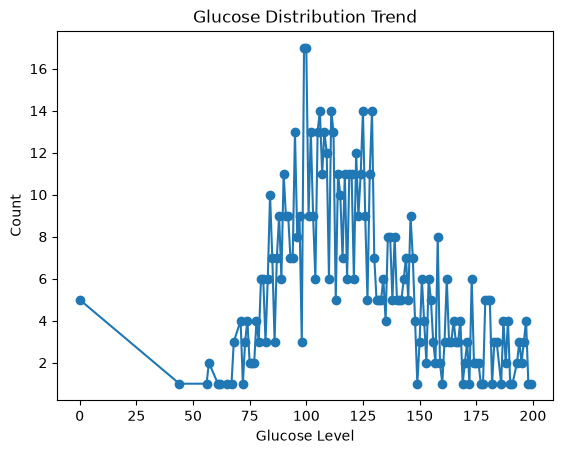

In [10]:
import matplotlib.pyplot as plt

counts = df['Glucose'].value_counts().sort_index()
plt.plot(counts.index, counts.values, marker='o')

plt.title("Glucose Distribution Trend")
plt.xlabel("Glucose Level")
plt.ylabel("Count")

plt.show()

The line chart shows that glucose values are most concentrated between approximately 90 and 130, where the frequency is highest. Lower and higher glucose levels have fewer occurrences, indicating that extreme values are less common.

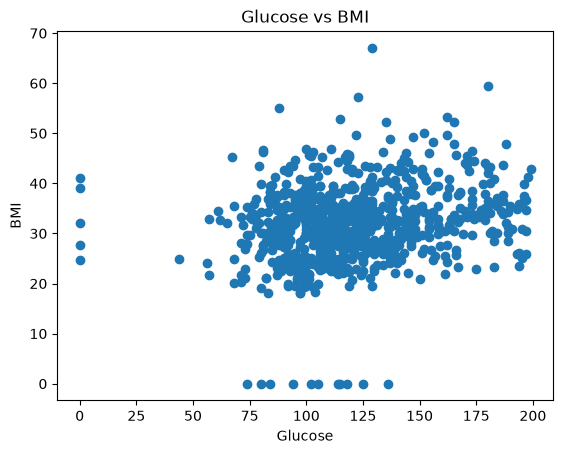

In [11]:
import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(df['Glucose'], df['BMI'])

plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")

plt.show()

<Axes: xlabel='Glucose', ylabel='BMI'>

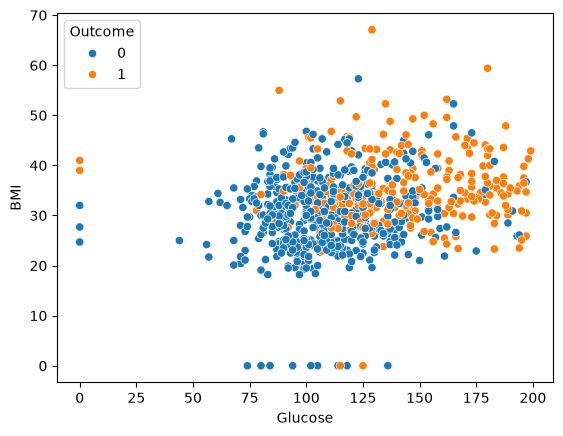

In [12]:

sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)

The scatter plot with hue shows the relationship between glucose levels and BMI, separated by outcome (0 = non-diabetic, 1 = diabetic). Most non-diabetic individuals are clustered around moderate glucose levels (80–130) and BMI values (20–35). Diabetic individuals are more concentrated at higher glucose levels (above 120) and slightly higher BMI ranges.

<Axes: >

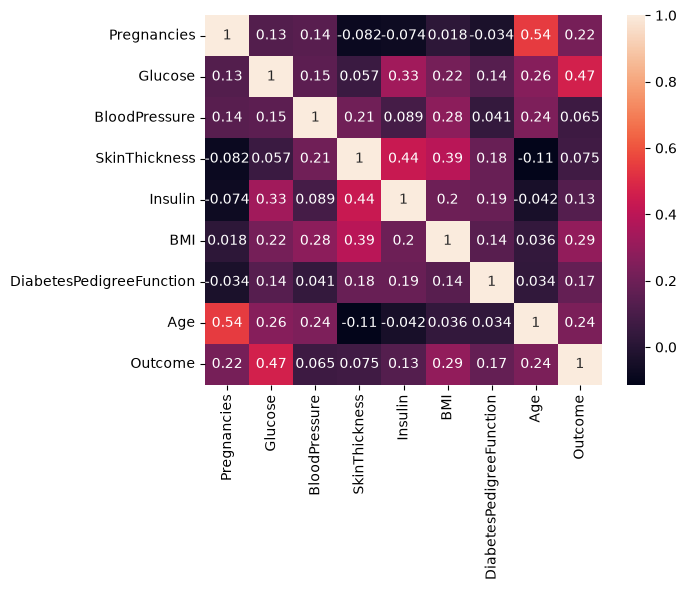

In [13]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)

The heatmap shows the correlation between different features in the dataset. Glucose has the highest positive correlation with the outcome (0.47), indicating it is the most important factor in predicting diabetes. BMI (0.29) and age (0.24) also show moderate positive relationships with the outcome. Pregnancies have a weaker positive correlation (0.22). Most other variables, such as blood pressure and skin thickness, show low or negligible correlation with the outcome. Additionally, age and pregnancies (0.54) have a strong positive relationship with each other. Overall, glucose appears to be the strongest predictor of diabetes in the dataset.

<Axes: xlabel='Age', ylabel='BMI'>

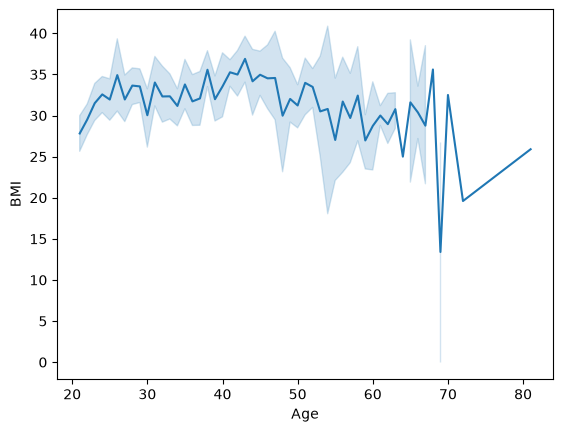

In [43]:
sns.lineplot(x='Age', y='BMI', data=df)

<Axes: xlabel='Outcome', ylabel='BMI'>

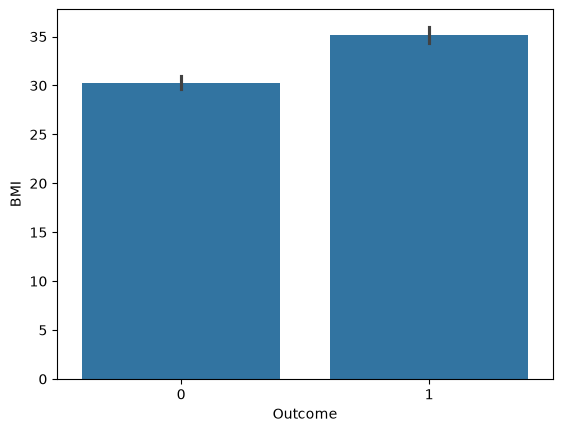

In [44]:
sns.barplot(x='Outcome', y='BMI', data=df)

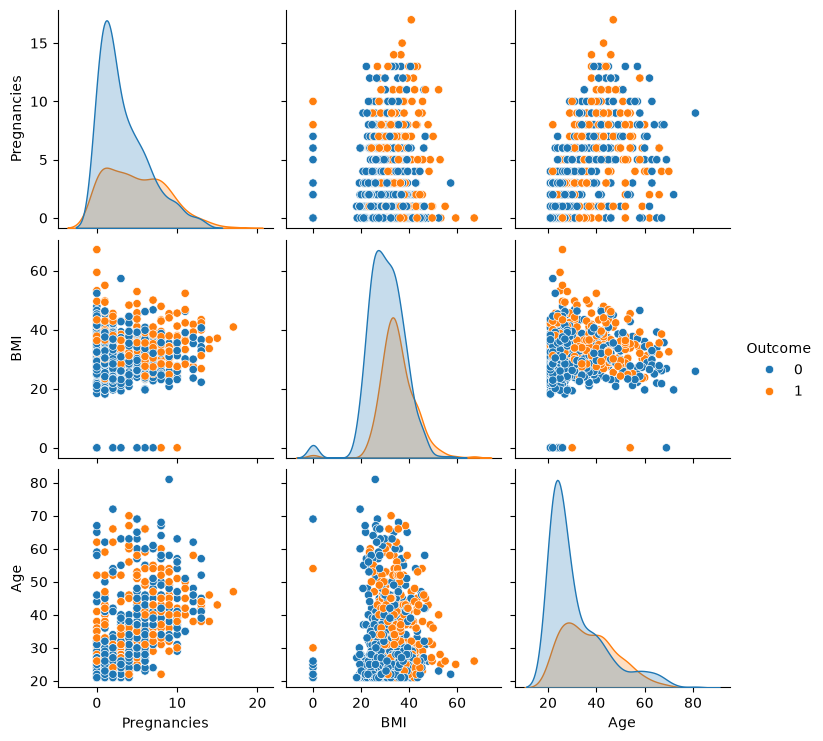

In [46]:
sns.pairplot(df[['Pregnancies','BMI','Age','Outcome']], hue='Outcome')

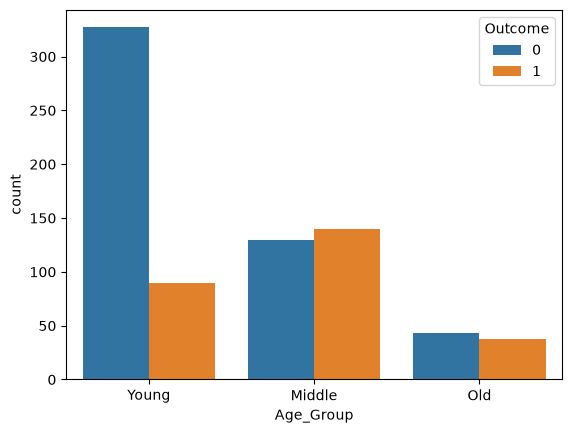

In [47]:
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0,30,50,100],
                         labels=['Young','Middle','Old'])

sns.countplot(x='Age_Group', hue='Outcome', data=df)
plt.show()